In [1]:
# Generic import 
import numpy as np
from os import listdir
# Train a model
from AutoencoderAPI.recurentTriplet import recurentTriplet
from AutoencoderAPI.utils.plot import load_run_results
# Define clustering
from AutoencoderAPI.autoencoderKmeans import autoencoder_kmeans

### Train a model

The first step is to choose an autoencoder architecture from the available options and optimize its hyperparameters.
The optimization can be done using the `sweep` method (futur document will be written on hyperparameter optimization).
The optimal architecture and parameters are case dependant but a simple architecture appears to be enough for most cases.

In [2]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/NIST (250) train",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250, 
        },
'network' : {
        'activation_list'          : ['GELU', 'GELU', 'PReLU', 'GELU', 'GELU'],
        'layer_list'               : [200, 100, 50, 1, 50, 100, 200],
        'layer_number'             : 4,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'TripletMSE', 
        'alpha'                    : 0.002,
        'epochs'                   : 6,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-6
        }
}

With the proper config dictionnary it is now possible to run an experiment and train our network.
A `run` folder with the date and time will be created in the specified path.

In [3]:
autoencoder = recurentTriplet()
#autoencoder.run(run_config_Triplet)

It is possible to directly analyse our results through the `load_run_results` function.

In [4]:
#load_run_results("Autoencoder Log/NIST (250)", 4, 30)

### Define clustering

If the autoencoder successfully accomplishes its intended task it is possible to fit our training data using a clustering method.
In this case th K-Means method is used since it is easily scalable.

First import the set on which the clustering is trained on.

In [5]:
signal_size = 250
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

X = np.concatenate((X_test,X_train))

In [6]:
ak = autoencoder_kmeans("Autoencoder Log/NIST (250)/fold 0")

Train the K-Means and define the interval of possible number of cluster

Clusters:   0%|          | 0/16 [00:00<?, ?it/s]

Number of clusters :  23
Silhouette score :  0.7040502


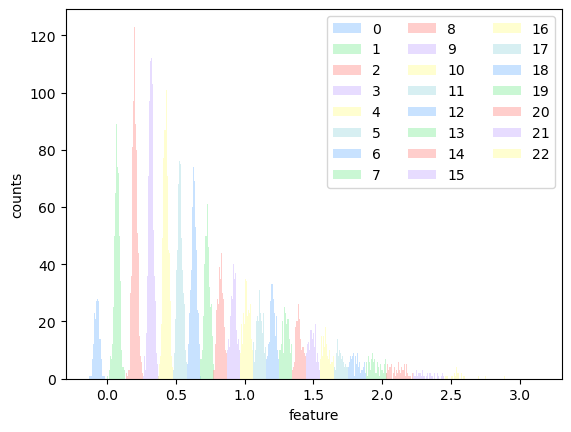

In [7]:
ak.fit_cluster(X, 15, 30, plot_clustering=True)

### From traces to labels

The `autoencoder_object` is now trained and initialized, it is possible to get the label of new traces by using the `get_label` function.

In [26]:
from timeit import default_timer as timer

start = timer()
ak.get_label(X)
end = timer()

print("Number of traces : ", len(X))
print("Number of traces per second : ",int(len(X) / (end - start)))

Number of traces :  143360
Number of traces per second :  1298533
